In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Introduction 

This machine learning project is based on the dataset indian_bikes, which contains information about different motorcycle brands and models in India. The dataset includes bike specifications, pricing details, GST values, mileage, top speed, fuel tank capacity, and customer behaviour factors.

The main objective of this project is to analyze the relationship between bike features and customer purchasing behaviour using machine learning techniques. 



### Data Description 

##### Dataset Features

| Column Name        | Description                                      |
|--------------------|--------------------------------------------------|
| brand              | Manufacturer company of the bike                 |
| model              | Name of the bike model                           |
| cc                 | Engine capacity in cubic centimeters             |
| segment            | Category of bike such as budget, mid, or premium |
|year                | Manufacturing or launch year                     |
|speedometer_type    | Type of speedometer used in the bike             |
|top_speed_kmh       | Maximum speed of the bike in km/h                |
|mileage_kmpl        | Fuel efficiency in kilometers per liter          |
|fuel_tank_litersFuel| tank capacity in liters                          |
|factory_price_inr   | Manufacturing price in Indian Rupees             |
|gst_rate_pct        |GST percentage applied to the bike                |
|gst_amount_inr      |GST amount in Indian Rupees                       |
|ex_showroom_inr     |Ex-showroom price of the bike                     |
|on_road_price_inr   |Final on-road price of the bike                   |
|overall_score       |Overall performance or rating score               |
|price_increase_scenario_pct|Percentage increase in bike price          |
|buyer_behaviour      | Customer reaction to price increase             |
|price_sensitivity    |Customer sensitivity towards price changes       |



In [2]:
df=pd.read_csv(r"c:\Users\nabee\Downloads\indian_bikes_dataset_1000.csv")
df

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,buyer_behaviour,price_sensitivity
0,Honda,Hornet 2.0,184,mid,2020,Digital,137,43.8,10.1,100781,28.0,28219,129000,147604,70,9.3,Will likely switch brand,High
1,Bajaj,Pulsar N250,249,mid,2024,Digital,157,33.2,14.9,123438,28.0,34562,158000,185890,71,4.1,Might reconsider,Medium
2,Hero,Splendor Plus,97,budget,2020,Analog,95,64.2,8.7,60156,28.0,16844,77000,89751,57,2.3,Might reconsider,Medium
3,Royal Enfield,Thunderbird 350X,346,premium,2025,Semi-Digital,152,29.1,17.3,146875,28.0,41125,188000,221689,67,8.7,Will likely switch brand,High
4,Royal Enfield,Scram 411,411,premium,2023,Semi-Digital,165,23.4,14.9,166412,31.0,51588,218000,251257,73,13.1,Will definitely switch,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Yamaha,R3,321,premium,2020,Digital,144,33.6,15.0,360938,28.0,101062,462000,530814,73,7.0,Will likely switch brand,High
996,Hero,Super Splendor,125,budget,2022,Semi-Digital,117,53.5,12.4,70312,28.0,19688,90000,107247,59,13.5,Will definitely switch,Very High
997,Bajaj,Platina 110 H-Gear,115,budget,2024,Semi-Digital,111,50.2,10.8,63281,28.0,17719,81000,97000,61,2.9,Might reconsider,Medium
998,TVS,Ronin,225,mid,2024,Digital,165,29.6,16.1,120312,28.0,33688,154000,180601,70,2.3,Might reconsider,Medium


### Data Inspection

1) Viewed first rows using "df.head"

2) Viewed last rows using "df.tail"

3) Checked shape using "df.shape"

4) Checked how many columns using "df.columns"

5) summary of the data structure "df.info()"

6) Null values using "df.isnull().sum()"

7) viewed dtypes "df.dtypes"

In [3]:
df.head()

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,buyer_behaviour,price_sensitivity
0,Honda,Hornet 2.0,184,mid,2020,Digital,137,43.8,10.1,100781,28.0,28219,129000,147604,70,9.3,Will likely switch brand,High
1,Bajaj,Pulsar N250,249,mid,2024,Digital,157,33.2,14.9,123438,28.0,34562,158000,185890,71,4.1,Might reconsider,Medium
2,Hero,Splendor Plus,97,budget,2020,Analog,95,64.2,8.7,60156,28.0,16844,77000,89751,57,2.3,Might reconsider,Medium
3,Royal Enfield,Thunderbird 350X,346,premium,2025,Semi-Digital,152,29.1,17.3,146875,28.0,41125,188000,221689,67,8.7,Will likely switch brand,High
4,Royal Enfield,Scram 411,411,premium,2023,Semi-Digital,165,23.4,14.9,166412,31.0,51588,218000,251257,73,13.1,Will definitely switch,Very High


In [4]:
df.tail()

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,buyer_behaviour,price_sensitivity
995,Yamaha,R3,321,premium,2020,Digital,144,33.6,15.0,360938,28.0,101062,462000,530814,73,7.0,Will likely switch brand,High
996,Hero,Super Splendor,125,budget,2022,Semi-Digital,117,53.5,12.4,70312,28.0,19688,90000,107247,59,13.5,Will definitely switch,Very High
997,Bajaj,Platina 110 H-Gear,115,budget,2024,Semi-Digital,111,50.2,10.8,63281,28.0,17719,81000,97000,61,2.9,Might reconsider,Medium
998,TVS,Ronin,225,mid,2024,Digital,165,29.6,16.1,120312,28.0,33688,154000,180601,70,2.3,Might reconsider,Medium
999,Royal Enfield,Meteor 350,349,premium,2024,Semi-Digital,153,31.4,13.2,164062,28.0,45938,210000,243807,72,7.5,Will likely switch brand,High


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   brand                        1000 non-null   object 
 1   model                        1000 non-null   object 
 2   cc                           1000 non-null   int64  
 3   segment                      1000 non-null   object 
 4   year                         1000 non-null   int64  
 5   speedometer_type             1000 non-null   object 
 6   top_speed_kmh                1000 non-null   int64  
 7   mileage_kmpl                 1000 non-null   float64
 8   fuel_tank_liters             1000 non-null   float64
 9   factory_price_inr            1000 non-null   int64  
 10  gst_rate_pct                 1000 non-null   float64
 11  gst_amount_inr               1000 non-null   int64  
 12  ex_showroom_inr              1000 non-null   int64  
 13  on_road_price_inr  

In [6]:
df.columns

Index(['brand', 'model', 'cc', 'segment', 'year', 'speedometer_type',
       'top_speed_kmh', 'mileage_kmpl', 'fuel_tank_liters',
       'factory_price_inr', 'gst_rate_pct', 'gst_amount_inr',
       'ex_showroom_inr', 'on_road_price_inr', 'overall_score',
       'price_increase_scenario_pct', 'buyer_behaviour', 'price_sensitivity'],
      dtype='object')

In [7]:
df.isnull().sum()

brand                          0
model                          0
cc                             0
segment                        0
year                           0
speedometer_type               0
top_speed_kmh                  0
mileage_kmpl                   0
fuel_tank_liters               0
factory_price_inr              0
gst_rate_pct                   0
gst_amount_inr                 0
ex_showroom_inr                0
on_road_price_inr              0
overall_score                  0
price_increase_scenario_pct    0
buyer_behaviour                0
price_sensitivity              0
dtype: int64

The **Indian_Bike Dataset** has no missing values,that was clean.

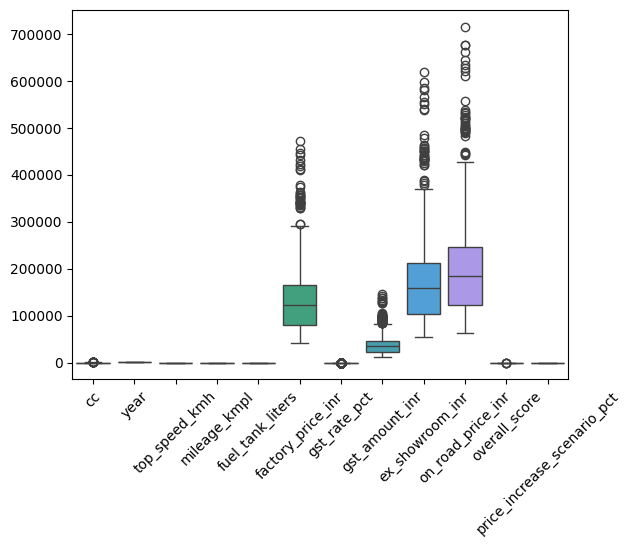

In [8]:
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

#### Checking the Outliers 
 
 ##### To see the outliers in :

 a) cc
 
 b) factory_price_inr

 c) gst_rate_pct

 d) gst_amount_inr

 c) ex_showroom_inr

 d) on_road_price_inr

 e)overall_score
 
To remove the Outliers 

 1) Q1,Q2,Q3 method 

 2) find IQR  

 3) calculate upper limit and lower limit 

 4) check outlier using outlier function 
 
 5) remove outliers using "df.drop()"

In [9]:

Q1=df['cc'].quantile(0.25)
Q2= df['cc'].quantile(0.50)
Q3=df['cc'].quantile(0.75)
print("Q1",Q1)
print("Q2",Q2)
print("Q3",Q3)

IQR=Q3-Q1
print("IQR",IQR)

upper=Q3+1.5*IQR
print("upper",upper)
lower=Q1-1.5*IQR
print(lower)

Q1 125.0
Q2 184.0
Q3 327.25
IQR 202.25
upper 630.625
-178.375


In [10]:
outlier=[]
for x in df['cc']:
    if (x>upper) or (x<lower):
     outlier.append(x)
outlier    

[648,
 648,
 648,
 648,
 648,
 648,
 648,
 648,
 648,
 648,
 648,
 648,
 648,
 648,
 648,
 648,
 648,
 648,
 648,
 648,
 648,
 648,
 648,
 648,
 648]

In [11]:
df=df[(df['cc']>=lower) & (df['cc']<=upper)]

In [12]:
outlier=[]
for x in df['cc']:
    if (x>upper) or (x<lower):
     outlier.append(x)
outlier    

[]

In [13]:
# factory_price_inr 

Q1=df['factory_price_inr'].quantile(0.25)
Q2= df['factory_price_inr'].quantile(0.50)
Q3=df['factory_price_inr'].quantile(0.75)
print("Q1",Q1)
print("Q2",Q2)
print("Q3",Q3)

IQR=Q3-Q1
print("IQR",IQR)

upper=Q3+1.5*IQR
print("upper",upper)
lower=Q1-1.5*IQR
print(lower)

Q1 80078.5
Q2 121875.0
Q3 162500.0
IQR 82421.5
upper 286132.25
-43553.75


In [14]:
outlier=[]
for x in df['factory_price_inr']:
    if (x>upper) or (x<lower):
     outlier.append(x)
outlier   

[373438,
 337500,
 296183,
 431298,
 339062,
 332031,
 341406,
 346094,
 289313,
 356250,
 295420,
 412977,
 339062,
 329688,
 471756,
 342188,
 442748,
 291603,
 350781,
 378125,
 351562,
 362500,
 345312,
 335156,
 336719,
 357812,
 446565,
 423664,
 410687,
 352344,
 357031,
 419847,
 340625,
 455725,
 352344,
 339062,
 329688,
 360938]

In [15]:
df=df[(df['factory_price_inr']>=lower) & (df['factory_price_inr']<=upper)]

In [16]:
outlier=[]
for x in df['factory_price_inr']:
    if (x>upper) or (x<lower):
     outlier.append(x)
outlier 

[]

In [17]:
#  gst_rate_pct
Q1=df['gst_rate_pct'].quantile(0.25)
Q2= df['gst_rate_pct'].quantile(0.50)
Q3=df['gst_rate_pct'].quantile(0.75)
print("Q1",Q1)
print("Q2",Q2)
print("Q3",Q3)

IQR=Q3-Q1
print("IQR",IQR)

upper=Q3+1.5*IQR
print("upper",upper)
lower=Q1-1.5*IQR
print(lower)

Q1 28.0
Q2 28.0
Q3 28.0
IQR 0.0
upper 28.0
28.0


In [18]:
outlier=[]
for x in df['gst_rate_pct']:
    if (x>upper) or (x<lower):
     outlier.append(x)
outlier  

[31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0,
 31.0]

In [19]:
df=df[(df['gst_rate_pct']>=lower) & (df['gst_rate_pct']<=upper)]

In [20]:
outlier=[]
for x in df['gst_rate_pct']:
    if (x>upper) or (x<lower):
     outlier.append(x)
outlier  

[]

In [21]:
# gst_amount_inr

Q1=df['gst_amount_inr'].quantile(0.25)
Q2= df['gst_amount_inr'].quantile(0.50)
Q3=df['gst_amount_inr'].quantile(0.75)
print("Q1",Q1)
print("Q2",Q2)
print("Q3",Q3)

IQR=Q3-Q1
print("IQR",IQR)

upper=Q3+1.5*IQR
print("upper",upper)
lower=Q1-1.5*IQR
print(lower)

Q1 21000.0
Q2 31500.0
Q3 39812.0
IQR 18812.0
upper 68030.0
-7218.0


In [22]:
outlier=[]
for x in df['gst_amount_inr']:
    if (x>upper) or (x<lower):
     outlier.append(x)
outlier 

[]

In [23]:
df=df[(df['gst_amount_inr']>=lower) & (df['gst_amount_inr']<=upper)]

In [24]:
outlier=[]
for x in df['gst_amount_inr']:
    if (x>upper) or (x<lower):
     outlier.append(x)
outlier 

[]

In [25]:
# ex_showroom_inr

Q1=df['ex_showroom_inr'].quantile(0.25)
Q2= df['ex_showroom_inr'].quantile(0.50)
Q3=df['ex_showroom_inr'].quantile(0.75)
print("Q1",Q1)
print("Q2",Q2)
print("Q3",Q3)

IQR=Q3-Q1
print("IQR",IQR)

upper=Q3+1.5*IQR
print("upper",upper)
lower=Q1-1.5*IQR
print(lower)

Q1 96000.0
Q2 144000.0
Q3 182000.0
IQR 86000.0
upper 311000.0
-33000.0


In [26]:
outlier=[]
for x in df['ex_showroom_inr']:
    if (x>upper) or (x<lower):
     outlier.append(x)
outlier 

[]

In [27]:
df=df[(df['ex_showroom_inr']>=lower) & (df['ex_showroom_inr']<=upper)]

In [28]:
outlier=[]
for x in df['ex_showroom_inr']:
    if (x>upper) or (x<lower):
     outlier.append(x)
outlier 

[]

In [29]:
# on_road_price_inr

Q1=df['on_road_price_inr'].quantile(0.25)
Q2= df['on_road_price_inr'].quantile(0.50)
Q3=df['on_road_price_inr'].quantile(0.75)
print("Q1",Q1)
print("Q2",Q2)
print("Q3",Q3)

IQR=Q3-Q1
print("IQR",IQR)

upper=Q3+1.5*IQR
print("upper",upper)
lower=Q1-1.5*IQR
print(lower)

Q1 111783.75
Q2 167712.5
Q3 210747.75
IQR 98964.0
upper 359193.75
-36662.25


In [30]:
outlier=[]
for x in df['on_road_price_inr']:
    if (x>upper) or (x<lower):
     outlier.append(x)
outlier 

[]

In [31]:
# overall_score

Q1=df['overall_score'].quantile(0.25)
Q2= df['overall_score'].quantile(0.50)
Q3=df['overall_score'].quantile(0.75)
print("Q1",Q1)
print("Q2",Q2)
print("Q3",Q3)

IQR=Q3-Q1
print("IQR",IQR)

upper=Q3+1.5*IQR
print("upper",upper)
lower=Q1-1.5*IQR
print(lower)

Q1 65.0
Q2 70.0
Q3 74.0
IQR 9.0
upper 87.5
51.5


In [32]:
outlier=[]
for x in df['overall_score']:
    if (x>upper) or (x<lower):
     outlier.append(x)
outlier 

[88, 51, 51, 50]

In [33]:
df=df[(df['overall_score']>=lower) & (df['overall_score']<=upper)]

In [34]:
outlier=[]
for x in df['overall_score']:
    if (x>upper) or (x<lower):
     outlier.append(x)
outlier 

[]

In [36]:
df.shape

(834, 18)

## Reset Dataset

Using "df.reset_index(drop=True,inplace=True)"

In [ ]:
df.reset_index(drop=True,inplace=True)

In [ ]:
df

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,buyer_behaviour,price_sensitivity
0,Honda,Hornet 2.0,184,mid,2020,Digital,137,43.8,10.1,100781,28.0,28219,129000,147604,70,9.3,Will likely switch brand,High
1,Bajaj,Pulsar N250,249,mid,2024,Digital,157,33.2,14.9,123438,28.0,34562,158000,185890,71,4.1,Might reconsider,Medium
2,Hero,Splendor Plus,97,budget,2020,Analog,95,64.2,8.7,60156,28.0,16844,77000,89751,57,2.3,Might reconsider,Medium
3,Royal Enfield,Thunderbird 350X,346,premium,2025,Semi-Digital,152,29.1,17.3,146875,28.0,41125,188000,221689,67,8.7,Will likely switch brand,High
4,TVS,Star City Plus,109,budget,2020,Semi-Digital,92,73.2,8.5,60938,28.0,17062,78000,93929,71,5.5,Will likely switch brand,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829,Honda,CB200X,184,mid,2022,Digital,121,45.4,13.1,108594,28.0,30406,139000,161891,79,2.9,Might reconsider,Medium
830,Hero,Super Splendor,125,budget,2022,Semi-Digital,117,53.5,12.4,70312,28.0,19688,90000,107247,59,13.5,Will definitely switch,Very High
831,Bajaj,Platina 110 H-Gear,115,budget,2024,Semi-Digital,111,50.2,10.8,63281,28.0,17719,81000,97000,61,2.9,Might reconsider,Medium
832,TVS,Ronin,225,mid,2024,Digital,165,29.6,16.1,120312,28.0,33688,154000,180601,70,2.3,Might reconsider,Medium


 # Exploratory Data Analysis

 Exploratory Data Analysis (EDA) was performed on the dataset indian_bikes_dataset to understand the structure, trends, and relationships between bike specifications, pricing details, and customer behaviour.


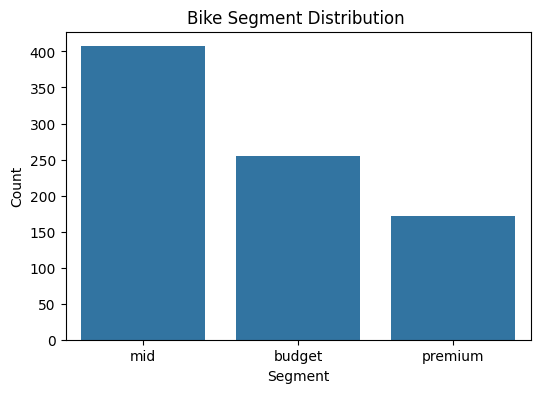

In [ ]:

# bike segment

plt.figure(figsize=(6,4))
sns.countplot(x='segment',data=df)
plt.title("Bike Segment Distribution ")
plt.xlabel("Segment")
plt.ylabel("Count")

plt.show()

The count plot shows the distribution of motorcycles across different bike segments in the dataset.

1) Mid segment bikes have the highest count in the dataset.
2) Budget bikes are the second most common category.
3) Premium bikes have the lowest number of entries.
4) This indicates that mid-range motorcycles are more popular and widely available in the Indian bike market.

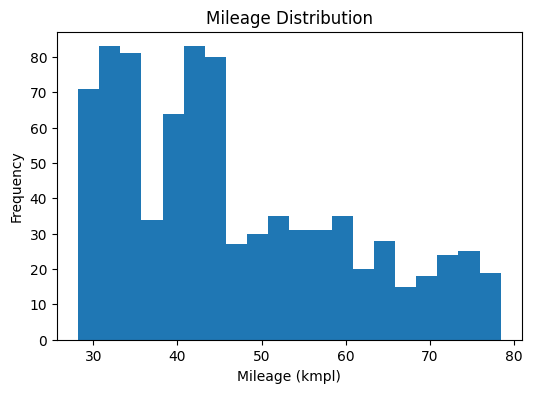

In [ ]:
# Milege

plt.figure(figsize=(6,4))
plt.hist(df['mileage_kmpl'], bins=20)
plt.title("Mileage Distribution")
plt.xlabel("Mileage (kmpl)")
plt.ylabel("Frequency")
plt.show()

The histogram represents the distribution of bike mileage (kmpl) in the dataset.

1) Most bikes have mileage between 30 kmpl and 50 kmpl.
2) A smaller number of bikes provide mileage above 60 kmpl.
3) Budget bikes generally offer higher mileage for better fuel efficiency.
4) Premium and high-performance bikes usually provide lower mileage because of larger engine capacity.
5) The graph shows that medium mileage bikes are most common in the Indian motorcycle market.

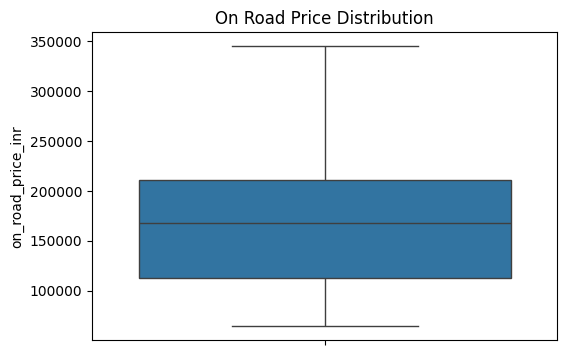

In [ ]:
# on road price 

plt.figure(figsize=(6,4))
sns.boxplot(y='on_road_price_inr', data=df)
plt.title("On Road Price Distribution")
plt.show()

The box plot shows the distribution of the on-road prices of bikes in the dataset.

1) The median on-road price is around the middle of the dataset, indicating an average market price range.
2) Most bike prices are concentrated between approximately ₹1,10,000 and ₹2,10,000.
3) The upper whisker extends to higher values, showing the presence of expensive premium bikes.
4) Lower-priced bikes belong mainly to the budget segment.

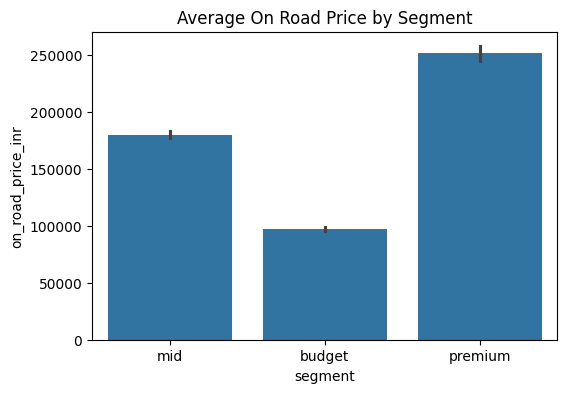

In [ ]:
#  Average Price by Segment

plt.figure(figsize=(6,4))
sns.barplot(x='segment', y='on_road_price_inr', data=df)
plt.title("Average On Road Price by Segment")
plt.show()

The bar plot reveals a clear, statistically distinct hierarchy in vehicle pricing across the three market segments. There is a strong, positive correlation between the premium tier of a segment and its average on-road price in INR.


1) Premium Segment: This has the highest average on-road price, peaking just above ₹250,000.

2) Mid Segment: This occupies the middle tier, with an average on-road price hovering around ₹180,000.

3) Budget Segment: This is the most affordable tier, with the lowest average on-road price, sitting slightly below ₹100,000.

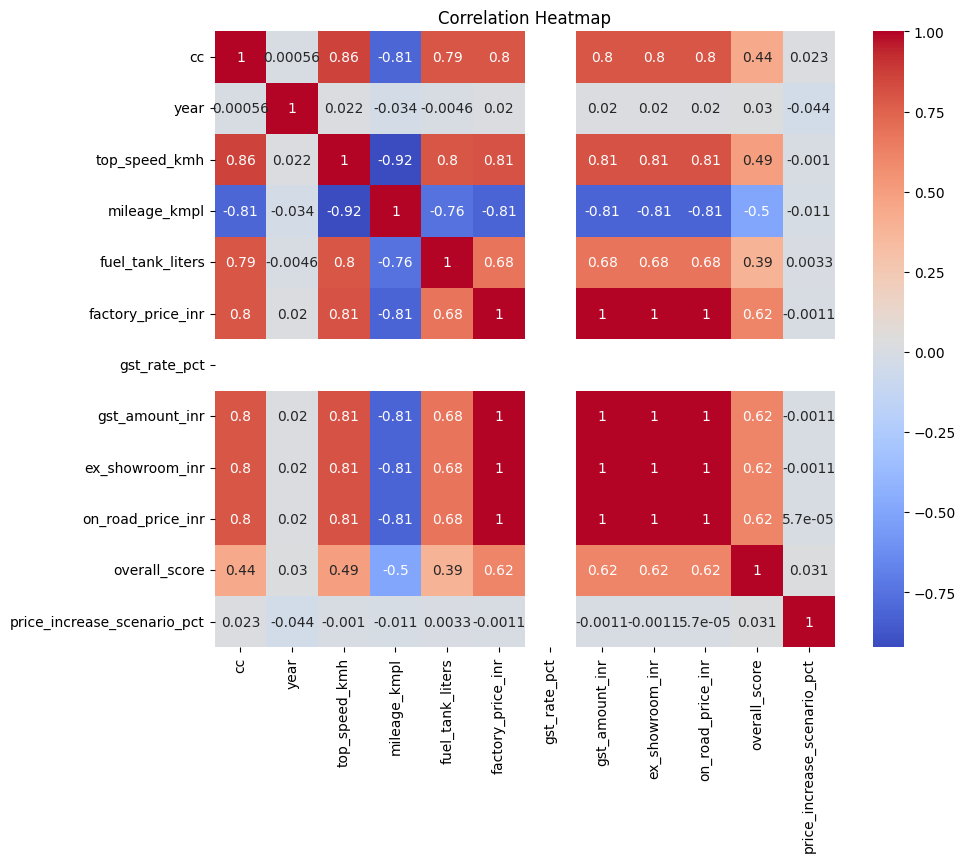

In [ ]:
num_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Heatmap Analysis for Indian Bike Dataset

1) factory_price_inr, gst_amount_inr, ex_showroom_inr, and on_road_price_inr show a strong positive correlation because higher factory prices increase GST and final bike prices.

2) cc and top_speed_kmh are positively correlated, meaning bikes with larger engine capacity generally have higher top speeds.

3) mileage_kmpl shows a negative correlation with cc and top_speed_kmh, indicating that high-performance bikes usually provide lower mileage.

4) overall_score has moderate positive relationships with performance-related features such as engine capacity and top speed.

The heatmap helps identify important features that influence pricing, performance, and customer behaviour in the dataset.

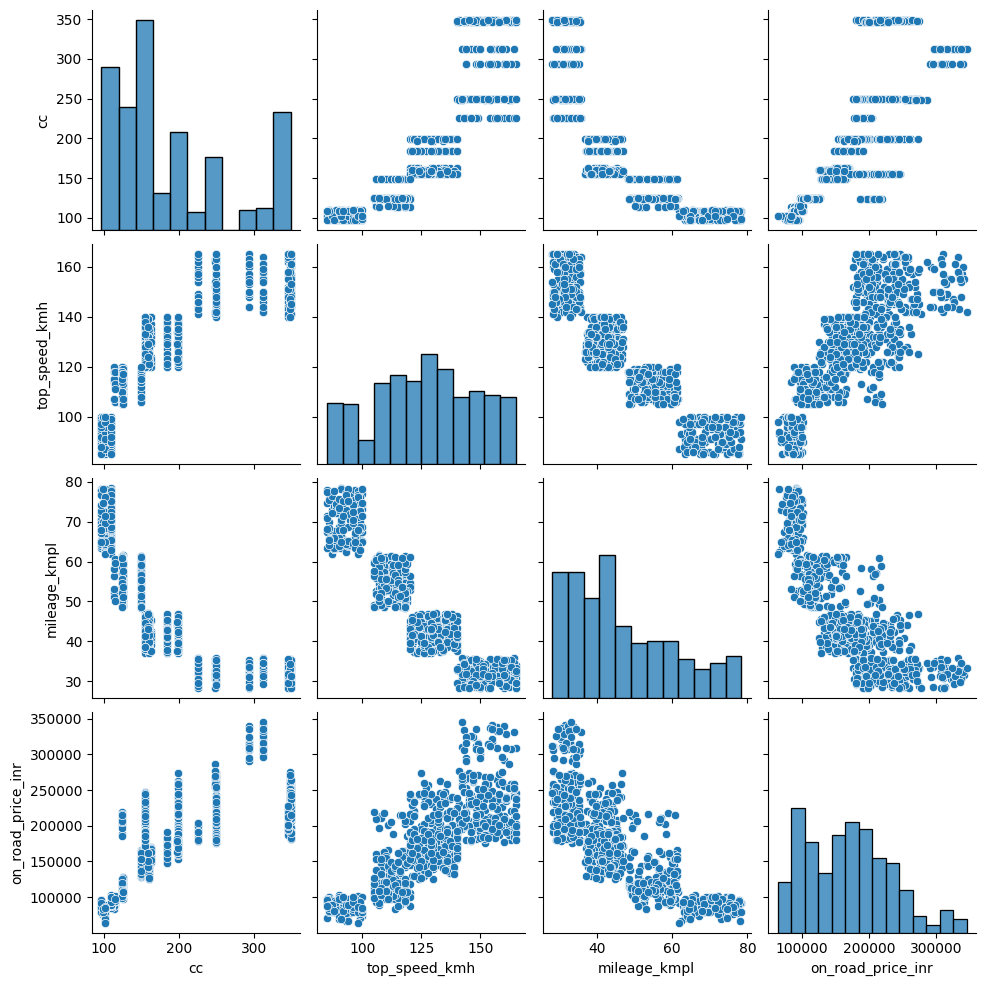

In [ ]:
sns.pairplot(df[['cc','top_speed_kmh',
                 'mileage_kmpl',
                 'on_road_price_inr']])
plt.show()

The pair plot is used to visualize relationships between multiple numerical features in the dataset.
It shows how engine capacity (cc), top speed, mileage, and on-road price are related to each other.

1) Bikes with higher cc generally have higher top speed.
2) Higher engine capacity bikes usually have lower mileage.
3) On-road price increases as engine capacity and performance increase.
4) The diagonal graphs show the distribution of each individual feature.
5) The scatter plots help identify trends, patterns, and feature relationships.”


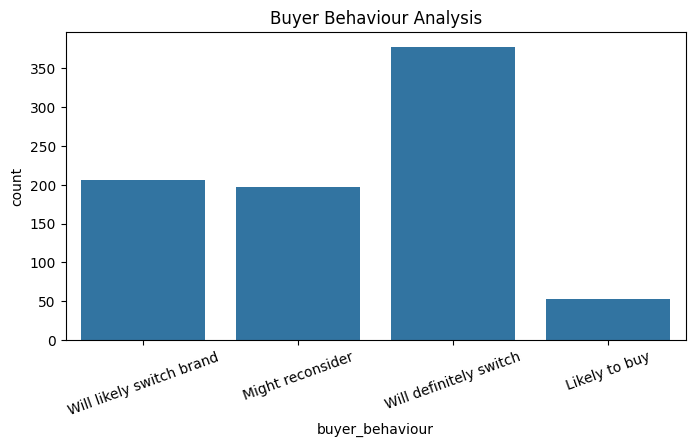

In [ ]:
#  Buyer Behaviour Count Plot

plt.figure(figsize=(8,4))
sns.countplot(x='buyer_behaviour', data=df)
plt.xticks(rotation=20)
plt.title("Buyer Behaviour Analysis")
plt.show()

The buyer behaviour count plot shows the number of customers in each buyer behaviour category.

1) Many customers are likely to reconsider or switch brands when prices increase.

2) Fewer customers remain unaffected by price changes.

3) The graph helps understand customer reactions toward bike price increases.

4) It also helps analyze market demand and customer price sensitivity.”


## Feature Engineering & Preprocessing

### Encoding  using Label encoding

Encoding means converting categorical/text data into numbers because ML models work with numerical values.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

In [ ]:
for i in ['buyer_behaviour','brand','model','segment','speedometer_type','price_sensitivity']:
    df[i]=le.fit_transform(df[i])

### Scaling the dataset 

#### Define X and Y  :

1) x : to decide first "Dependent Variable" and then "df.

drop" to the categorical values in axis 1.

2) y : to add dropped values. 

3) Using  the "StandardScaler" to "fit_transform" method  

by the x Variable.

4) create x1 Variable and convert on "pd.DataFrame" 

then  include numerical column names. 

5) Add "x1,y" in axis=1 using "pd.concat"

6) checking "max,min"  using  "describe()"

In [ ]:
x=df.drop('buyer_behaviour',axis=1)

In [ ]:
y=df['buyer_behaviour']

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scale=StandardScaler()

In [ ]:
x_scale=scale.fit_transform(x)
print(x_scale[:5])

[[-0.55061274 -0.20344796 -0.07485799  0.14045039 -1.58090641 -0.26008212
   0.47785418 -0.20517956 -0.92318131 -0.3044897   0.         -0.30446223
  -0.30448369 -0.35198901  0.08737069  0.33591345 -1.55096854]
 [-1.3863016   0.43204117  0.73143085  0.14045039  0.79901407 -0.26008212
   1.40456126 -0.98343048  0.69510455  0.22233529  0.          0.22228298
   0.22232385  0.25749841  0.24109887 -0.94635875  0.08534741]
 [-0.96845717  1.12530204 -1.15404459 -1.27082218 -1.58090641 -1.7769247
  -1.46823071  1.29258635 -1.39518136 -1.24911013  0.         -1.24908257
  -1.2491041  -1.27296994 -1.91109561 -1.3902222   0.08534741]
 [ 0.28507612  1.356389    1.93466189  1.55172296  1.39399419  1.25676046
   1.17288449 -1.28445206  1.50424749  0.76729699  0.          0.76729777
   0.76729716  0.82739446 -0.37381384  0.18795896 -1.55096854]
 [ 1.12076497  1.24084552 -1.00519127 -1.27082218 -1.58090641  1.25676046
  -1.60723677  1.95336543 -1.46260994 -1.23092691  0.         -1.23097908
  -1.2309

In [ ]:
x1=pd.DataFrame(x_scale,columns=['brand', 'model', 'cc', 'segment', 'year', 'speedometer_type',
       'top_speed_kmh', 'mileage_kmpl', 'fuel_tank_liters',
       'factory_price_inr', 'gst_rate_pct', 'gst_amount_inr',
       'ex_showroom_inr', 'on_road_price_inr', 'overall_score',
       'price_increase_scenario_pct', 'price_sensitivity'])

In [ ]:
x2=pd.concat([x1,y],axis=1)
x2

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,price_sensitivity,buyer_behaviour
0,-0.550613,-0.203448,-0.074858,0.140450,-1.580906,-0.260082,0.477854,-0.205180,-0.923181,-0.304490,0.0,-0.304462,-0.304484,-0.351989,0.087371,0.335913,-1.550969,3
1,-1.386302,0.432041,0.731431,0.140450,0.799014,-0.260082,1.404561,-0.983430,0.695105,0.222335,0.0,0.222283,0.222324,0.257498,0.241099,-0.946359,0.085347,1
2,-0.968457,1.125302,-1.154045,-1.270822,-1.580906,-1.776925,-1.468231,1.292586,-1.395181,-1.249110,0.0,-1.249083,-1.249104,-1.272970,-1.911096,-1.390222,0.085347,1
3,0.285076,1.356389,1.934662,1.551723,1.393994,1.256760,1.172884,-1.284452,1.504247,0.767297,0.0,0.767298,0.767297,0.827394,-0.373814,0.187959,-1.550969,3
4,1.120765,1.240846,-1.005191,-1.270822,-1.580906,1.256760,-1.607237,1.953365,-1.462610,-1.230927,0.0,-1.230979,-1.230938,-1.206459,0.241099,-0.601132,-1.550969,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829,-0.550613,-1.301111,-0.074858,0.140450,-0.390946,-0.260082,-0.263511,-0.087708,0.088247,-0.122820,0.0,-0.122846,-0.122826,-0.124550,1.470924,-1.242268,0.085347,1
830,-0.968457,1.298617,-0.806720,-1.270822,-0.390946,1.256760,-0.448853,0.506993,-0.147753,-1.012961,0.0,-1.012907,-1.012949,-0.994445,-1.603639,1.371595,0.903505,2
831,-1.386302,0.200954,-0.930765,-1.270822,0.799014,1.256760,-0.726865,0.264708,-0.687181,-1.176447,0.0,-1.176419,-1.176441,-1.157571,-1.296183,-1.242268,0.085347,1
832,1.120765,0.894215,0.433724,0.140450,0.799014,-0.260082,1.775244,-1.247742,1.099676,0.149649,0.0,0.149703,0.149661,0.173301,0.087371,-1.390222,0.085347,1


In [ ]:
x2.describe()

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,price_sensitivity,buyer_behaviour
count,8.340000e+02,8.340000e+02,8.340000e+02,8.340000e+02,8.340000e+02,8.340000e+02,8.340000e+02,8.340000e+02,8.340000e+02,8.340000e+02,834.0,8.340000e+02,8.340000e+02,8.340000e+02,8.340000e+02,8.340000e+02,834.000000,834.000000
mean,5.537803e-17,5.963788e-17,1.043663e-16,1.182108e-16,3.732373e-14,-1.490947e-16,-3.833864e-17,-1.363152e-16,4.217250e-16,1.618742e-16,0.0,1.464323e-16,-2.412139e-16,-1.107561e-16,9.627258e-16,1.405750e-16,0.000000,1.883693
std,1.000600e+00,1.000600e+00,1.000600e+00,1.000600e+00,1.000600e+00,1.000600e+00,1.000600e+00,1.000600e+00,1.000600e+00,1.000600e+00,0.0,1.000600e+00,1.000600e+00,1.000600e+00,1.000600e+00,1.000600e+00,1.000600,0.851324
min,-1.386302e+00,-1.647741e+00,-1.154045e+00,-1.270822e+00,-1.580906e+00,-1.776925e+00,-1.931584e+00,-1.350530e+00,-1.631181e+00,-1.648746e+00,0.0,-1.648771e+00,-1.648751e+00,-1.678849e+00,-2.679736e+00,-1.710790e+00,-1.550969,0.000000
25%,-9.684572e-01,-8.967088e-01,-8.191246e-01,-1.270822e+00,-9.859263e-01,-2.600821e-01,-7.268650e-01,-8.512747e-01,-7.546099e-01,-9.039545e-01,0.0,-9.039536e-01,-9.039543e-01,-9.163531e-01,-6.812702e-01,-8.723815e-01,-0.732811,1.000000
50%,-1.327683e-01,-1.246872e-03,-3.849691e-01,1.404504e-01,2.040340e-01,-2.600821e-01,6.083599e-02,-2.418895e-01,-1.140384e-01,-3.199722e-02,0.0,-3.199636e-02,-3.199703e-02,-2.826946e-02,8.737069e-02,-9.313682e-03,0.085347,2.000000
75%,1.120765e+00,8.942151e-01,7.314308e-01,1.404504e-01,7.990141e-01,1.256760e+00,8.022017e-01,7.125692e-01,3.916760e-01,6.583139e-01,0.0,6.582616e-01,6.583025e-01,6.532171e-01,7.022834e-01,8.290951e-01,0.903505,2.000000
max,1.538609e+00,1.703019e+00,1.971875e+00,1.551723e+00,1.393994e+00,1.256760e+00,1.775244e+00,2.335149e+00,2.380819e+00,2.747361e+00,0.0,2.747388e+00,2.747367e+00,2.792333e+00,2.393293e+00,1.741481e+00,0.903505,3.000000


In [ ]:
df=x2
df

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,price_sensitivity,buyer_behaviour
0,-0.550613,-0.203448,-0.074858,0.140450,-1.580906,-0.260082,0.477854,-0.205180,-0.923181,-0.304490,0.0,-0.304462,-0.304484,-0.351989,0.087371,0.335913,-1.550969,3
1,-1.386302,0.432041,0.731431,0.140450,0.799014,-0.260082,1.404561,-0.983430,0.695105,0.222335,0.0,0.222283,0.222324,0.257498,0.241099,-0.946359,0.085347,1
2,-0.968457,1.125302,-1.154045,-1.270822,-1.580906,-1.776925,-1.468231,1.292586,-1.395181,-1.249110,0.0,-1.249083,-1.249104,-1.272970,-1.911096,-1.390222,0.085347,1
3,0.285076,1.356389,1.934662,1.551723,1.393994,1.256760,1.172884,-1.284452,1.504247,0.767297,0.0,0.767298,0.767297,0.827394,-0.373814,0.187959,-1.550969,3
4,1.120765,1.240846,-1.005191,-1.270822,-1.580906,1.256760,-1.607237,1.953365,-1.462610,-1.230927,0.0,-1.230979,-1.230938,-1.206459,0.241099,-0.601132,-1.550969,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829,-0.550613,-1.301111,-0.074858,0.140450,-0.390946,-0.260082,-0.263511,-0.087708,0.088247,-0.122820,0.0,-0.122846,-0.122826,-0.124550,1.470924,-1.242268,0.085347,1
830,-0.968457,1.298617,-0.806720,-1.270822,-0.390946,1.256760,-0.448853,0.506993,-0.147753,-1.012961,0.0,-1.012907,-1.012949,-0.994445,-1.603639,1.371595,0.903505,2
831,-1.386302,0.200954,-0.930765,-1.270822,0.799014,1.256760,-0.726865,0.264708,-0.687181,-1.176447,0.0,-1.176419,-1.176441,-1.157571,-1.296183,-1.242268,0.085347,1
832,1.120765,0.894215,0.433724,0.140450,0.799014,-0.260082,1.775244,-1.247742,1.099676,0.149649,0.0,0.149703,0.149661,0.173301,0.087371,-1.390222,0.085347,1


## Model selection & training

 To select the**Target and independent variables** in X 
 
 and Y.The target variable is **'buyer_behaviour'**, and the 
 
 remaining features are used as input variables. The 
 
 data is then split into training and testing sets. A 
 
 machine learning model is selected and trained using 
 
 the training data, and its performance is evaluated on 
 
 the test data.


In [ ]:
x=df.drop('buyer_behaviour',axis=1)

In [ ]:
y=df['buyer_behaviour']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lg=LogisticRegression(max_iter=100)

In [ ]:
lg.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
y_pred=lg.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test,y_pred))

1.0


The Logistic Regression model achieved an accuracy score of 1.0 (100%), which means the model correctly predicted all test data samples without any errors.

In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test,y_pred))

[[11  0  0  0]
 [ 0 39  0  0]
 [ 0  0 76  0]
 [ 0  0  0 41]]


In [ ]:
from sklearn.svm import SVC

svm=SVC(kernel='rbf')

In [ ]:
svm.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
y_pred=svm.predict(x_test)

In [ ]:
print(accuracy_score(y_test,y_pred))

0.9760479041916168


The SVC model produced excellent prediction results with 97% accuracy and can be considered a strong model for predicting buyer behaviour or price sensitivity in the Indian bike dataset.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier(n_neighbors=7)

In [ ]:
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
y_pred=knn.predict(x_test)

In [ ]:
print(accuracy_score(y_test,y_pred))

0.9161676646706587


The KNN model provided strong classification performance with 91% accuracy, making it a reliable model for predicting buyer behaviour or price sensitivity in the Indian bike dataset.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt=DecisionTreeClassifier(max_depth=3,max_leaf_nodes=5,min_samples_split=7,random_state=42)

In [ ]:
dt.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node,

In [ ]:
y_pred=dt.predict(x_test)

In [ ]:
print(accuracy_score(y_test,y_pred))

1.0


The Decision Tree model achieved excellent performance with 100% accuracy and effectively classified the target variable in the Indian bike dataset.

# Documentation

#### Project Title

Indian Bike Market Analysis and Prediction Using Machine Learning

#### Objective 

The main objective of this project is to analyze Indian motorcycle data and build machine learning models to predict customer-related outcomes such as buyer behaviour or price sensitivity based on bike specifications and pricing details.

#### Dataset Used

1) Dataset Name: indian_bikes_dataset_1000.csv
2) Total Records: 1000
3) Dataset Type: Structured CSV dataset

#### Feature Used

1) Brand
2) Model
3) Engine Capacity (CC)
4) Segment
5) Year
6) Speedometer Type
7) Top Speed
8) Mileage
9) Fuel Tank Capacity
10) Factory Price
11) GST Rate
12) GST Amount
13) Ex-Showroom Price
14) On-Road Price
15) Overall Score
16) Price Increase Scenario
17) Buyer Behaviour
18) Price Sensitivity

#### Technologies Used

1) Python
2) Pandas
3) NumPy
4) Matplotlib
5) Seaborn
6) Scikit-learn

#### Machine Learning Algorithms Used

a) Logistic Regression


#### Data Preprocessing

1) Checked missing values
2) Removed duplicates
3) Encoded categorical features
4) Feature scaling using StandardScaler
5) Train-test splitting

#### Exploratory Data Analysis (EDA)

1) Histograms
2) Count plots
3) Box plots
4) Correlation heatmaps
5) Pair plots
6) Bar charts

#### Model Performance

| Model        |  Accuracy    |        
|--------------|--------------|
| Logistic Regression | 100%  |













# Conclusion 

This project successfully analyzed the Indian bike dataset and applied multiple machine learning algorithms to predict customer-related behaviour.

 Exploratory Data Analysis helped identify important relationships between bike specifications, pricing, mileage, and customer preferences.

The Logistic Regression model achieved an accuracy of 100%, indicating that the selected features effectively captured patterns related to buyer behaviour. The model was also tested with modified input values to observe how changes in bike characteristics influence customer responses.